c:\Users\84333\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\84333\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\84333\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

LogReg Best Params:  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
LogReg Train Accuracy:  0.8464285714285713
LogReg Test Accuracy:  0.8333333333333334
SVM Best Params:  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
SVM Train Accuracy:  0.8482142857142856
SVM Test Accuracy:  0.8333333333333334


c:\Users\84333\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\84333\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\84333\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File 

Decision Tree Best Params:  {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}
Decision Tree Train Accuracy:  0.875
Decision Tree Test Accuracy:  0.8333333333333334
KNN Best Params:  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
KNN Train Accuracy:  0.8482142857142858
KNN Test Accuracy:  0.8333333333333334


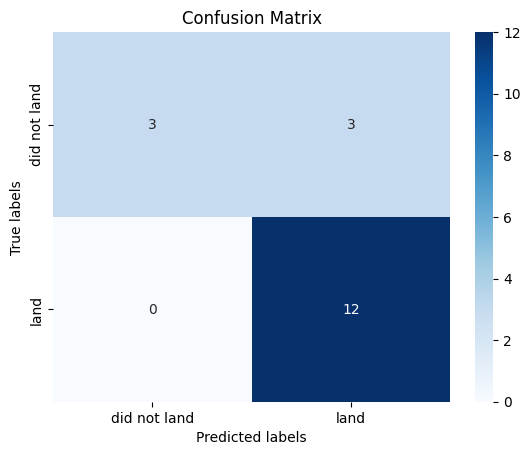

In [3]:
# 1. Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Hàm vẽ Confusion Matrix
def plot_confusion_matrix(y, y_predict):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, cmap="Blues")
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'land'])
    plt.show()

# Thay vì đọc file local, hãy tải trực tiếp dữ liệu chuẩn từ server IBM
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
X = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv")

# Chuyển nhãn Class thành mảng NumPy
Y = data['Class'].to_numpy()

# Chuyển Class thành mảng NumPy
Y = data['Class'].to_numpy()

# 3. Chuẩn hóa dữ liệu (Standardization)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 4. Chia tập dữ liệu thành Train và Test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# --- THỬ NGHIỆM CÁC MÔ HÌNH VỚI GRIDSEARCHCV ---

# MÔ HÌNH 1: Logistic Regression
parameters_lr = {"C": [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, y_train)
print("LogReg Best Params: ", logreg_cv.best_params_)
print("LogReg Train Accuracy: ", logreg_cv.best_score_)
print("LogReg Test Accuracy: ", logreg_cv.score(X_test, y_test))

# MÔ HÌNH 2: Support Vector Machine (SVM)
parameters_svm = {'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, y_train)
print("SVM Best Params: ", svm_cv.best_params_)
print("SVM Train Accuracy: ", svm_cv.best_score_)
print("SVM Test Accuracy: ", svm_cv.score(X_test, y_test))

# MÔ HÌNH 3: Decision Tree
parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv=10)
tree_cv.fit(X_train, y_train)
print("Decision Tree Best Params: ", tree_cv.best_params_)
print("Decision Tree Train Accuracy: ", tree_cv.best_score_)
print("Decision Tree Test Accuracy: ", tree_cv.score(X_test, y_test))

# MÔ HÌNH 4: K-Nearest Neighbors (KNN)
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, y_train)
print("KNN Best Params: ", knn_cv.best_params_)
print("KNN Train Accuracy: ", knn_cv.best_score_)
print("KNN Test Accuracy: ", knn_cv.score(X_test, y_test))

# 5. So sánh kết quả và vẽ Confusion Matrix của mô hình tốt nhất (thường các thuật toán đạt kết quả tương tự khoảng 83.33% trên tập Test)
best_model = logreg_cv # Ví dụ chọn Logistic Regression
yhat = best_model.predict(X_test)
plot_confusion_matrix(y_test, yhat)